# ***Ejercicio integrador - Clase 2***

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder
# Dataset
df = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "Maria", "Pedro", "Ana", "Luis"],
    "Edad": [32, -28, 40, 35, 50],
    "Nivel_Educativo": ["Licenciado", "Ingeniero", "Doctorado", "Licenciado", "Doctorado"],
    "Salario": [50000, 60000, None, 55000, 200000],
    "Categoria": ["Junior", "Senior", "Senior", "Junior", "Manager"],
    "Estado": ["Activo", "ACTIVO", "Inactivo", "Activo", "Inactivo"]
})

In [2]:
df

,ID,Nombre,Edad,Nivel_Educativo,Salario,Categoria,Estado
0,1,Juan,32,Licenciado,50000.0,Junior,Activo
1,2,Maria,-28,Ingeniero,60000.0,Senior,ACTIVO
2,3,Pedro,40,Doctorado,NaN,Senior,Inactivo
3,4,Ana,35,Licenciado,55000.0,Junior,Activo
4,5,Luis,50,Doctorado,200000.0,Manager,Inactivo


## Proceso KDD

1️. `Identificación de Tipos de Datos`

Clasifica cada columna según su tipo (numérico, categórico, ordinal, fecha) y
explica cómo se debería manejar cada una.

---




In [3]:
# Ver tipos de datos
print(df.dtypes)

ID                   int64
Nombre              object
Edad                 int64
Nivel_Educativo     object
Salario            float64
Categoria           object
Estado              object
dtype: object


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               5 non-null      int64  
 1   Nombre           5 non-null      object 
 2   Edad             5 non-null      int64  
 3   Nivel_Educativo  5 non-null      object 
 4   Salario          4 non-null      float64
 5   Categoria        5 non-null      object 
 6   Estado           5 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 412.0+ bytes
None


# **Clasificacion de datos segun su tipo**

**ID**: numérico (identificador)

**Nombre**: categórico (texto)

**Edad**: numérico (valores negativos en fila 1)

**Nivel Educativo**: categórico ordinal (Licenciado - Ingeniero - Doctorado)

**Salario:** numérico: (faltantes y outliers)

**Categoría**: categórico(Junior, Senior, Manager)

**Estado**: categórico (Activo-1 / Inactivo-0, con inconsistencias)

2️. `Limpieza de Datos`

•     Detecta y corrige valores faltantes en las columnas necesarias.

•     Identifica y elimina valores atípicos en la columna “Salario”.

•     Corrige inconsistencias en los datos categóricos (ejemplo: "Licenciado" y "licenciado" deben ser tratados como el mismo valor).

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder
# 1 Corrección de edad negativa
df["Edad"] = df["Edad"].abs()

#2 Imputación del salario faltante con la mediana
#df["Salario"].fillna(df["Salario"].median(), inplace=True)
df["Salario"] = df["Salario"].fillna(df["Salario"].median())

# 3 Detectar y eliminar valores atípicos con IQR
Q1, Q3 = df["Salario"].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df["Salario"] > (Q1 - 1.5 * IQR)) & (df["Salario"] < (Q3 + 1.5 * IQR))]

# 4 Unificar formato de columna Estado
#df["Estado"] = df["Estado"].str.lower()
#print(df)
df = df.copy()
df.loc[:, "Estado"] = df["Estado"].str.lower()
print(df)



   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado
0   1   Juan    32      Licenciado  50000.0    Junior    activo
1   2  Maria    28       Ingeniero  60000.0    Senior    activo
2   3  Pedro    40       Doctorado  57500.0    Senior  inactivo
3   4    Ana    35      Licenciado  55000.0    Junior    activo


3️. `Transformación de Datos`

•     Convierte las variables categóricas en numéricas utilizando codificación ordinal o One-Hot Encoding.

•     Aplica normalización al salario para facilitar comparaciones.

•     Crea una nueva variable “Años hasta jubilación” suponiendo que la edad de retiro es 65 años.

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder
# 5 Codificación ordinal para "Nivel Educativo"
encoder_ordinal = OrdinalEncoder(categories=[["Licenciado", "Ingeniero", "Doctorado"]])
df["Nivel_Cod"] = encoder_ordinal.fit_transform(df[["Nivel_Educativo"]])

# 6 Normalización del salario
scaler = MinMaxScaler()
df["Salario_Normalizado"] = scaler.fit_transform(df[["Salario"]])

# 7 Creación de nueva variable "Años hasta jubilación"
df["Años_Hasta_Jubilación"] = 65 - df["Edad"]

# 8 Convertir la variale categoria a numerica
encoder = LabelEncoder()
df["Estado_cod"] = encoder.fit_transform(df["Estado"])

# Invertir valores
df["Estado_cod"] = df["Estado_cod"].map({0: 1, 1: 0})

print(df)



   ID Nombre  Edad Nivel_Educativo  Salario Categoria    Estado  Nivel_Cod  \
0   1   Juan    32      Licenciado  50000.0    Junior    activo        0.0   
1   2  Maria    28       Ingeniero  60000.0    Senior    activo        1.0   
2   3  Pedro    40       Doctorado  57500.0    Senior  inactivo        2.0   
3   4    Ana    35      Licenciado  55000.0    Junior    activo        0.0   

   Salario_Normalizado  Años_Hasta_Jubilación  Estado_cod  
0                 0.00                     33           1  
1                 1.00                     37           1  
2                 0.75                     25           0  
3                 0.50                     30           1  


4. `Analisis Exploratorio de Datos con LLM`

EDA, Análisis Exploratorio de Datos: investigamos mediante estadísticas descriptivas y visualizaciones.

Uso de prompts

In [7]:
# Resumen estadístico
print(df.describe())

             ID       Edad       Salario  Nivel_Cod  Salario_Normalizado  \
count  4.000000   4.000000      4.000000   4.000000             4.000000   
mean   2.500000  33.750000  55625.000000   0.750000             0.562500   
std    1.290994   5.057997   4269.562819   0.957427             0.426956   
min    1.000000  28.000000  50000.000000   0.000000             0.000000   
25%    1.750000  31.000000  53750.000000   0.000000             0.375000   
50%    2.500000  33.500000  56250.000000   0.500000             0.625000   
75%    3.250000  36.250000  58125.000000   1.250000             0.812500   
max    4.000000  40.000000  60000.000000   2.000000             1.000000   

       Años_Hasta_Jubilación  Estado_cod  
count               4.000000        4.00  
mean               31.250000        0.75  
std                 5.057997        0.50  
min                25.000000        0.00  
25%                28.750000        0.75  
50%                31.500000        1.00  
75%           

# **Visualizaciones**

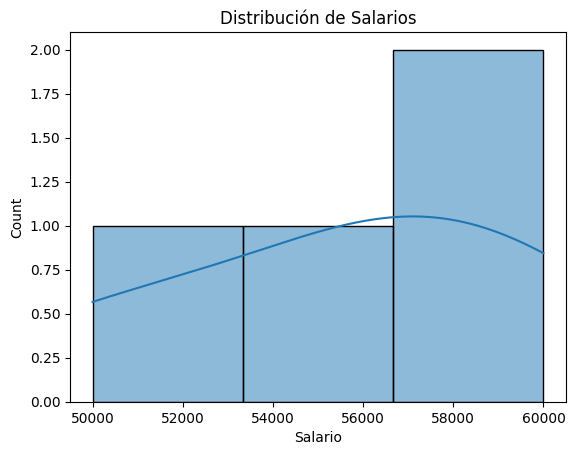

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Salario"], kde=True)
plt.title("Distribución de Salarios")
plt.show()


**Visualización 1: Distribución de Salarios**

En el histograma se observa que los salarios se distribuyen entre 50.000 y 60.000, con una mayor concentración en los valores más altos del rango (alrededor de 55.000–60.000).

No se observan valores extremos, lo que indica que el proceso de eliminación de outliers fue adecuado.
Además, la distribución no es completamente uniforme debido a la poca cantidad de datos, pero permite identificar un rango salarial relativamente homogéneo dentro de la empresa.

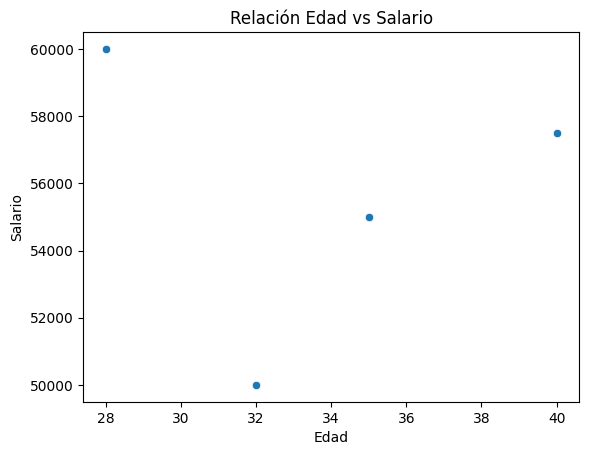

In [9]:
sns.scatterplot(x="Edad", y="Salario", data=df)
plt.title("Relación Edad vs Salario")
plt.show()

**Visualización 2: Relación Edad vs Salario**

El gráfico de dispersión muestra que no existe una relación lineal clara entre la edad y el salario.

Esto indica que el salario no depende únicamente de la edad, sino que probablemente está influenciado por otros factores como el nivel educativo o la categoría laboral.


**Conclusión del EDA**

El análisis exploratorio muestra que los salarios se concentran en un rango medio y relativamente homogéneo.

Además, no se evidencia una relación directa entre edad y salario, lo que sugiere que existen otras variables relevantes en la determinación de los ingresos.

##Promp utilizado en ChatGPT

Prompt 1

**Consulta:**
"¿Qué gráficos son más adecuados para analizar la relación entre edad, salario y nivel educativo?"

**Síntesis:**

El LLM sugirió usar histogramas para distribución, scatter plots para relaciones entre variables numéricas y boxplots para comparar salarios según categorías. También recomendó usar colores para diferenciar niveles educativos.

**Validación propia:**

Estos gráficos permiten visualizar tanto distribución como relaciones entre variables, facilitando la interpretación.


Prompt 2

**Consulta:**
"¿Qué errores comunes se cometen en el preprocesamiento de datos?"

**Síntesis:**

El LLM mencionó errores como no tratar valores faltantes, ignorar outliers y no escalar variables numéricas.

**Validación propia:**

Coincide con el proceso realizado, donde se abordaron estos problemas en etapas de limpieza y transformación.


Link:

https://colab.research.google.com/drive/15GguBUIDkAutaD01EdNyAzomOS7T2Obt?usp=sharing